In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt


In [3]:
np.random.seed(42)
x, y = make_circles(n_samples=500, noise=0.35, factor=0.1, random_state=42)
x_train, x_test, y_train, x_test = train_test_split(x, y, test_size=0.2)

In [4]:
x.shape

(500, 2)

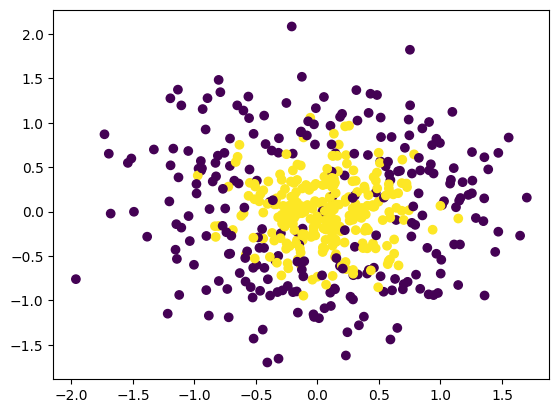

In [5]:
plt.scatter(x[:, 0], x[:, 1], c=y)

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

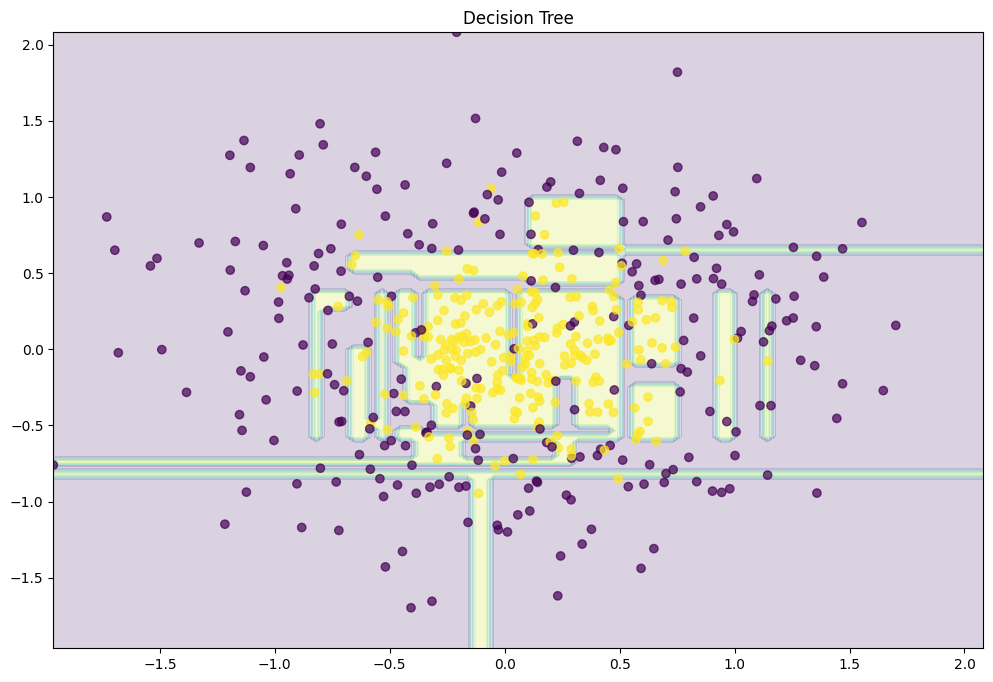

In [8]:
plt.figure(figsize=(12, 8))
x_range = np.linspace(x.min(), x.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dt.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.7)
plt.title("Decision Tree")
plt.show() # this fully drawn decision tree is overfitting as we can see it is trying to cover all yellow points even if those should be purple as there are maximum purple points


In [9]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(x_train, y_train)


RandomForestClassifier(n_estimators=500, random_state=42)

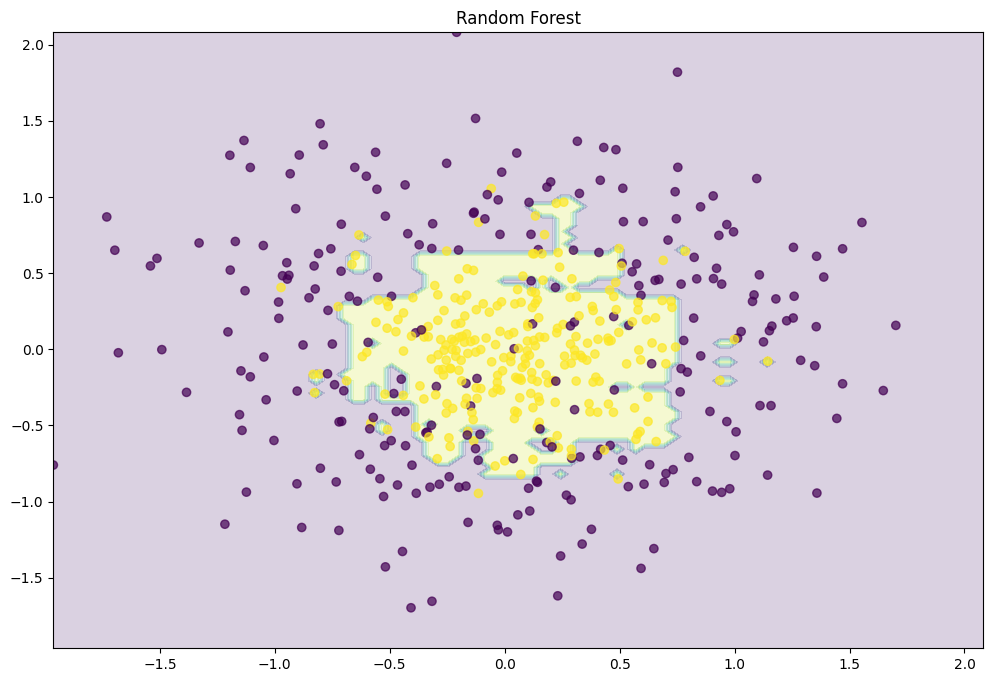

In [10]:
plt.figure(figsize=(12, 8))
x_range = np.linspace(x.min(), x.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.7)
plt.title("Random Forest")
plt.show() # now here there is no overfitting with a better low bias and low variance model, here some-what but to a less amount bias is increased
# as we can see some yellow points treated as purple but still it is a better algo

In [11]:
n_train = 150
n_test = 1000
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

x_train, y_train = generate(n_samples=n_train, noise=noise)
x_test, y_test = generate(n_samples=n_test, noise=noise)


(-5.0, 5.0)

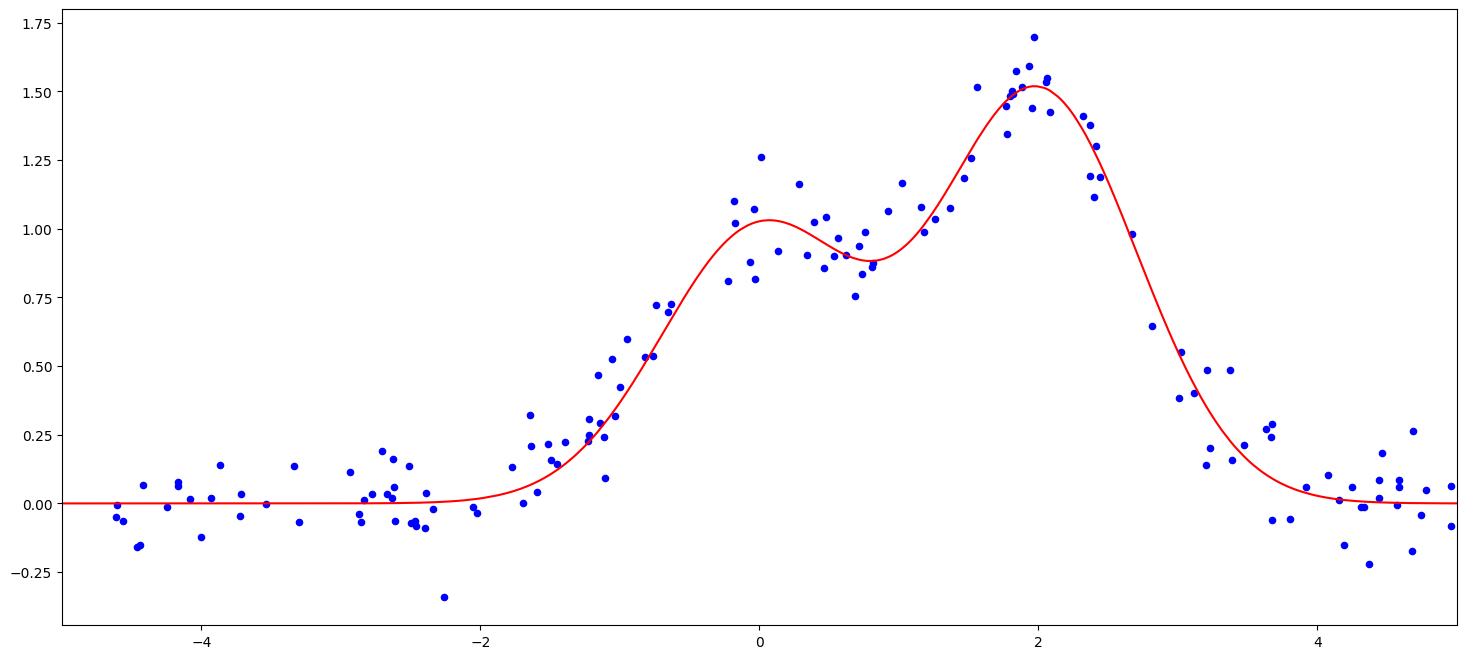

In [13]:
plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.xlim([-5, 5])



Text(0.5, 1.0, 'Decision tree, MSE = 22.70')

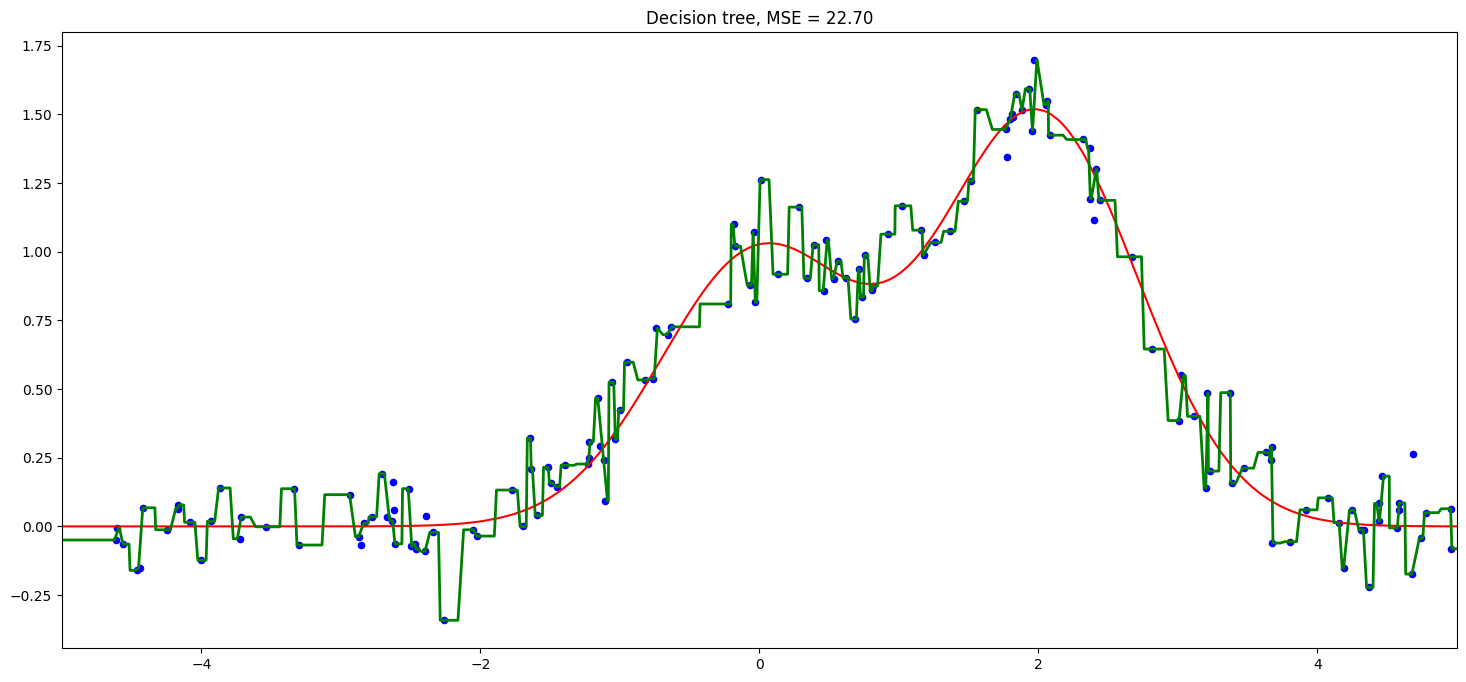

In [14]:
# One decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(x_train, y_train)
d_predict = dtree.predict(x_test)

plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f"
          % np.sum((y_test - d_predict) ** 2))

Text(0.5, 1.0, 'Random Forest, MSE = 15.73')

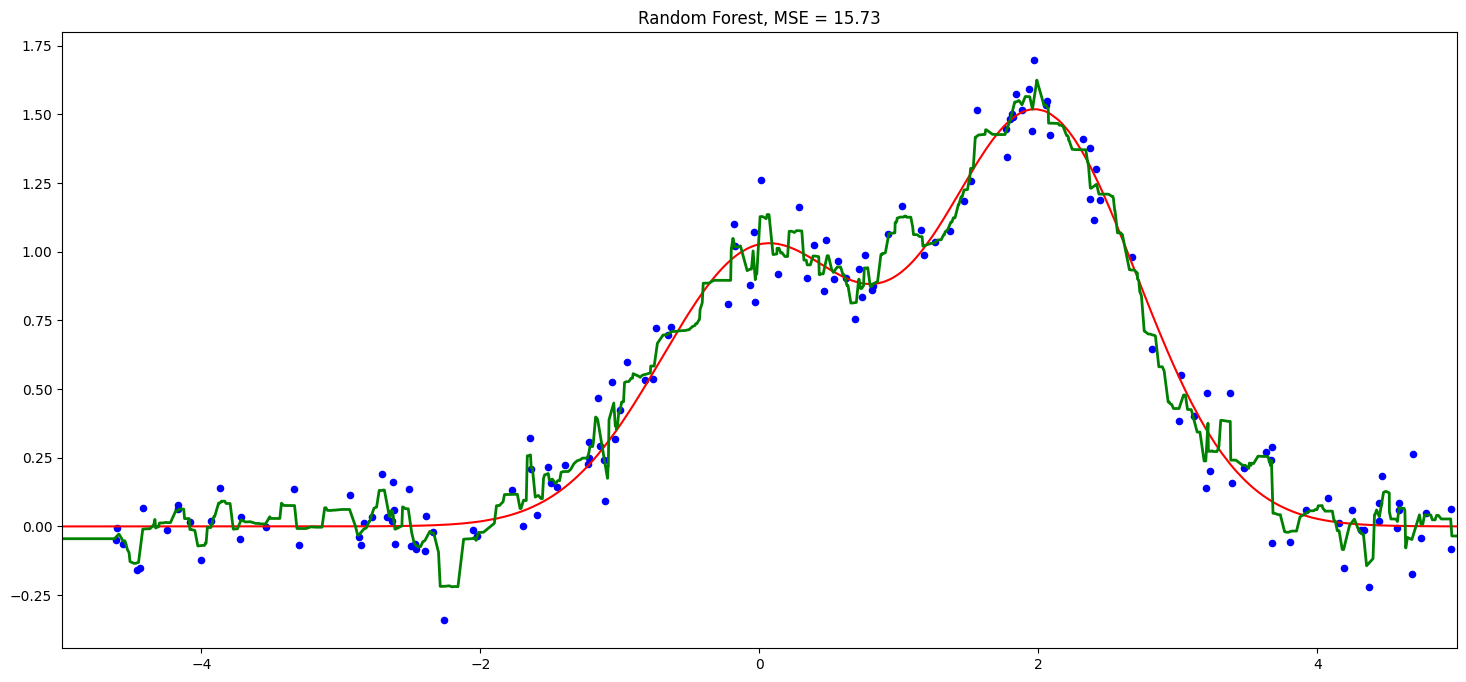

In [20]:
# One Random Forest regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=1000).fit(x_train, y_train)
rf_predict = rf.predict(x_test)

plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random Forest, MSE = %.2f"
          % np.sum((y_test - rf_predict) ** 2))